# UR10 Simple Reach — RTDE Control Loop

Deploy the trained 6-DOF reaching policy on a real UR10 (or URSim) via RTDE.

**Observation (18D):** `q[6], qd[6], tcp_pos[3], target_pos[3]`  
**Action (6D):** delta joint positions, scaled by `action_scale=0.04`  
**Control:** `ctrl_next = clip(ctrl_prev + action_scale * action, lowers, uppers)`

## 1 — Backend setup

In [1]:
import os
import platform
import subprocess

os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

system = platform.system()
if system == "Darwin":
    os.environ["MUJOCO_GL"] = "glfw"
    os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
    print("macOS — MUJOCO_GL=glfw, JAX on CPU")
elif subprocess.run(["nvidia-smi"], capture_output=True).returncode == 0:
    os.environ["MUJOCO_GL"] = "egl"
    print("NVIDIA GPU detected — MUJOCO_GL=egl")
else:
    os.environ["MUJOCO_GL"] = "osmesa"
    os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
    print("No GPU — MUJOCO_GL=osmesa, JAX on CPU")

macOS — MUJOCO_GL=glfw, JAX on CPU


## 2 — Imports

In [2]:
import json
import time

import jax
import matplotlib.pyplot as plt
import mediapy as media
import numpy as np

from URSim_RTDE_dependencies import URSimRTDESimpleReach

print("JAX devices:", jax.devices())

Failed to import warp: No module named 'warp'
Failed to import mujoco.mjx.third_party.mujoco_warp as mujoco_warp: No module named 'warp'
JAX devices: [CpuDevice(id=0)]


## 3 — Configuration

In [3]:
HOST = "127.0.0.1"          # URSim or real robot IP

# Target position in world frame (meters) — choose within UR10e workspace
TARGET_POS = np.array([0.5, 0.0, 0.5])

# Control loop settings (must match training: ctrl_dt=0.02 → 50 Hz)
CONTROL_HZ = 50.0
ACTION_SCALE = 0.04          # same as training env
TIMEOUT_S = 10.0

# Start pose — "low_home" keyframe from mjx_reach.xml
Q_START = [0, -1.7, 2.25, -2.15, -1.5, -1.5]

# MuJoCo XML for replay rendering
XML_PATH = "../../mujoco_playground/_src/manipulation/my_ur10/xmls/mjx_reach.xml"

# servoj parameters
LOOKAHEAD_TIME = 0.1
GAIN = 300

## 4 — Connect to robot & verify

In [4]:
robot = URSimRTDESimpleReach(host=HOST)
robot.connect()
robot.print_feedback()

q      = [0.2727, 0.1763, -0.933, 0.877, 2.7091, 1.4694]
qd     = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
tcp_xyz= [-0.6944, -0.2387, 0.2532]


## 5 — Load policy

In [5]:
robot.load_policy_fn(
    policy_path="../../evaluation/downloaded_policies/simple_reach_policy",
    env_name="UR10SimpleReach",
    deterministic=True,
)

[load_policy_fn] Loaded from: ../../evaluation/downloaded_policies/simple_reach_policy
  env=UR10SimpleReach  obs=18  act=6
  ctrl limits: [-6.2831 -6.2831 -3.1415 -6.2831 -6.2831 -6.2831] .. [6.2831 6.2831 3.1415 6.2831 6.2831 6.2831]


## 6 — JIT warmup
First JAX call triggers XLA compilation (~1-3s on CPU). Do this before the control loop.

In [6]:
dummy_obs = np.zeros((1, 18), dtype=np.float32)
t0 = time.perf_counter()
_ = robot._policy_fn(dummy_obs)
_.block_until_ready()  # ensure JIT compilation completes
print(f"JIT warmup done in {time.perf_counter() - t0:.2f}s")

JIT warmup done in 0.04s


## 7 — Move to start pose

In [7]:
robot.move_to_start(Q_START, a=1.5, v=1.0, timeout_s=15.0, tol=0.01)

Moving to start pose with movej (a=1.5, v=1.0)...
  err=0.0001  q=[ 0.   -1.7   2.25 -2.15 -1.5  -1.5 ]140e+00 -1.486e+00 -1.490e+00]
  Reached start in 7.30s


## 8 — Run policy control loop

In [8]:
df, stats = robot.run_policy_loop(
    target_pos=TARGET_POS,
    control_hz=CONTROL_HZ,
    timeout_s=TIMEOUT_S,
    action_scale=ACTION_SCALE,
    lookahead_time=LOOKAHEAD_TIME,
    gain=GAIN,
)
print(f"\nLogged {len(df)} steps")

[ 499] tcp→tgt=0.9828m | hz=45.3 | tcp=[ 0.444  0.51  -0.338]
Policy loop finished.

Logged 500 steps


## 9 — Timing statistics

In [9]:
print("=== Summary ===")
robot.print_stats(stats)

print(f"\n=== Timing breakdown (mean / max) ===")
print(f"  RTDE receive : {df['obs_time_s'].mean()*1000:6.2f} / {df['obs_time_s'].max()*1000:6.2f} ms")
print(f"  Policy infer : {df['policy_time_s'].mean()*1000:6.2f} / {df['policy_time_s'].max()*1000:6.2f} ms")
print(f"  servoj send  : {df['send_time_s'].mean()*1000:6.2f} / {df['send_time_s'].max()*1000:6.2f} ms")
total_compute = df['obs_time_s'] + df['policy_time_s'] + df['send_time_s']
print(f"  Total compute: {total_compute.mean()*1000:6.2f} / {total_compute.max()*1000:6.2f} ms")
print(f"  Available dt : {1000/CONTROL_HZ:6.2f} ms")
print(f"  Overruns     : {stats.get('num_overruns', 0)}")

=== Summary ===
  requested_control_hz: 50.000000
  timeout_s: 10.000000
  num_samples: 500
  total_time_s: 10.004135
  total_wall_time_s: 10.004597
  true_inferred_frequency_hz: 49.877073
  mean_loop_dt_true_s: 0.019507
  std_loop_dt_true_s: 0.001933
  mean_loop_hz_true: 51.777092
  mean_obs_time_s: 0.000018
  mean_policy_time_s: 0.000170
  mean_send_time_s: 0.000360
  max_obs_time_s: 0.000148
  max_policy_time_s: 0.000720
  max_send_time_s: 0.000558
  start_tcp_to_target_dist: 0.919342
  final_tcp_to_target_dist: 0.982841
  min_tcp_to_target_dist: 0.757261
  net_improvement: -0.063499
  mean_tcp_speed_mps: 0.750745
  max_tcp_speed_mps: 1.666880
  mean_qd_norm: 2.798074
  max_qd_norm: 5.051256
  mean_cmd_err_norm: 1.308241
  max_cmd_err_norm: 2.337391
  num_overruns: 0
  overrun_ratio: 0.000000

=== Timing breakdown (mean / max) ===
  RTDE receive :   0.02 /   0.15 ms
  Policy infer :   0.17 /   0.72 ms
  servoj send  :   0.36 /   0.56 ms
  Total compute:   0.55 /   1.21 ms
  Availabl

## 10 — Plots

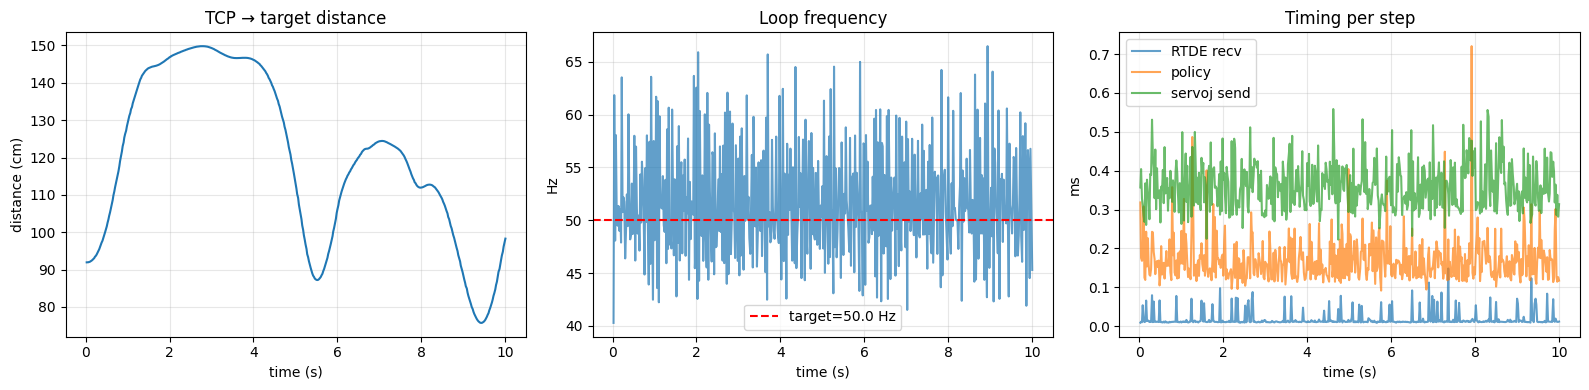

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# TCP -> target distance
axes[0].plot(df["time"], df["tcp_to_target_dist"] * 100)
axes[0].set_xlabel("time (s)")
axes[0].set_ylabel("distance (cm)")
axes[0].set_title("TCP → target distance")
axes[0].grid(True, alpha=0.3)

# Loop frequency
axes[1].plot(df["time"], df["loop_hz_true"], alpha=0.7)
axes[1].axhline(CONTROL_HZ, color="r", ls="--", label=f"target={CONTROL_HZ} Hz")
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("Hz")
axes[1].set_title("Loop frequency")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Timing breakdown
axes[2].plot(df["time"], df["obs_time_s"] * 1000, label="RTDE recv", alpha=0.7)
axes[2].plot(df["time"], df["policy_time_s"] * 1000, label="policy", alpha=0.7)
axes[2].plot(df["time"], df["send_time_s"] * 1000, label="servoj send", alpha=0.7)
axes[2].set_xlabel("time (s)")
axes[2].set_ylabel("ms")
axes[2].set_title("Timing per step")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11 — MuJoCo video replay

Render the logged trajectory in MuJoCo with the red target sphere visible.
Uses stride-based decimation to match real-time speed.

In [11]:
mj = robot.mujoco_init_model(
    xml_path=XML_PATH,
    height=480,
    width=640,
    cam_lookat=(0.4, 0.0, 0.4),
    cam_distance=1.8,
    cam_azimuth=130,
    cam_elevation=-20,
)

VIDEO_FPS = 30.0
frames, actual_fps = robot.render_video_from_log(mj, df, video_fps=VIDEO_FPS)

# Display inline
media.show_video(frames, fps=actual_fps, height=480)

[render_video_from_log] logged_hz=51.8, stride=2, effective_video_fps=25.9
  Rendered 250 frames from 500 logged steps


This browser does not support the video tag.


### Optional: save video to disk

In [12]:
robot.save_video(frames, out_path="simple_reach_replay.mp4", fps=actual_fps)

ValueError: Could not find a backend to open `simple_reach_replay.mp4`` with iomode `w?`.
Based on the extension, the following plugins might add capable backends:
  FFMPEG:  pip install imageio[ffmpeg]
  pyav:  pip install imageio[pyav]

## 12 — Frequency analysis

Understand the timing budget and maximum achievable control frequency.

In [ ]:
print("=== Frequency analysis ===")
compute_ms = (df["obs_time_s"] + df["policy_time_s"] + df["send_time_s"]) * 1000
print(f"Mean compute time: {compute_ms.mean():.2f} ms")
print(f"Max  compute time: {compute_ms.max():.2f} ms")
print(f"P95  compute time: {compute_ms.quantile(0.95):.2f} ms")
print(f"")
max_hz_mean = 1000.0 / compute_ms.mean()
max_hz_p95 = 1000.0 / compute_ms.quantile(0.95)
print(f"Max sustainable Hz (mean):  {max_hz_mean:.0f} Hz")
print(f"Max sustainable Hz (p95):   {max_hz_p95:.0f} Hz")
print(f"")
print(f"Training ctrl_dt = 0.02s → 50 Hz")
print(f"Achieved loop Hz: {stats['mean_loop_hz_true']:.1f} Hz")
print(f"")

# Video rendering frequency analysis
print("=== Video rendering analysis ===")
logged_hz = df["loop_hz_true"].mean()
for target_fps in [15, 25, 30, 50]:
    stride = max(1, round(logged_hz / target_fps))
    effective_fps = logged_hz / stride
    real_time_ratio = effective_fps / logged_hz * stride  # should be ~1.0 for real-time
    n_frames = len(df) // stride
    print(f"  target={target_fps:2d} fps → stride={stride}, effective={effective_fps:.1f} fps, "
          f"{n_frames} frames, duration={n_frames/effective_fps:.1f}s")

## 13 — Disconnect

In [ ]:
robot.disconnect()
print("Disconnected.")